In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import torch
from JacobianODE.control.gramians import compute_all_gramians

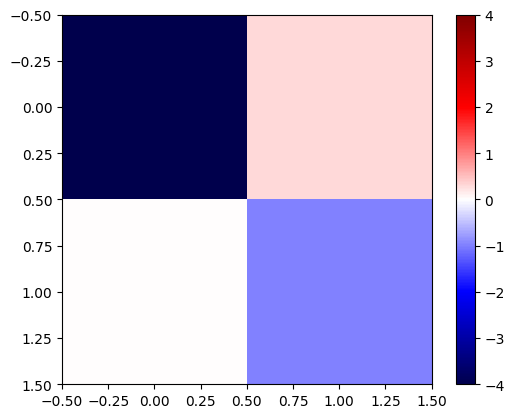

In [3]:
Lambda = np.zeros((2, 2))
lambda_1 = 1
lambda_2 = 4
Lambda[0, 0] = -lambda_1
Lambda[1, 1] = -lambda_2
inv_coupling_const = 10
e1 = np.array([1, 1])
e2 = np.array([inv_coupling_const, 0])
V = np.array([e1, e2])
V_inv = np.linalg.inv(V)
A = V @ Lambda @ V_inv

# Choose a diverging colormap centered at zero: 'seismic' is white(ish) at zero, blue/red at extremes
plt.imshow(A, cmap='seismic', vmin=-np.max(np.abs(A)), vmax=np.max(np.abs(A)))
plt.colorbar()
plt.show()

In [4]:
lambda_1_vals = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01]
inv_coupling_const_vals = [10, 5, 3, 2, 1, 0.5, 0.3, 0.1, 0.05, 0.01]

## Sweep λ₁ × inverse-coupling: area 2 → area 1 reach / ctrl log_trace

Cartesian product of the two value lists (every (λ₁, inv_coupling)
pair). For each pair, rebuild `A` exactly as the cell above (λ₂ and
`e1=[1,1]` fixed, `e2=[inv_coupling, 0]`), then the **canonical**
area 2 → area 1 reach/ctrl `log_trace`
(`compute_all_gramians(..., rescale=True)`, `logsumexp(spec)`).
Here `A = [[-λ₂, (λ₂-λ₁)/icc], [0, -λ₁]]`, so `A_used = -λ₂` (const),
`B = (λ₂-λ₁)/icc`, `C = A[1,0] = 0` always ⇒ obs degenerate (`W_o≡0`);
reach/ctrl are C-independent so a unit-C placeholder is used solely to
keep the bundled call defined. Two grids: rows = inv_coupling_const_vals,
cols = lambda_1_vals.

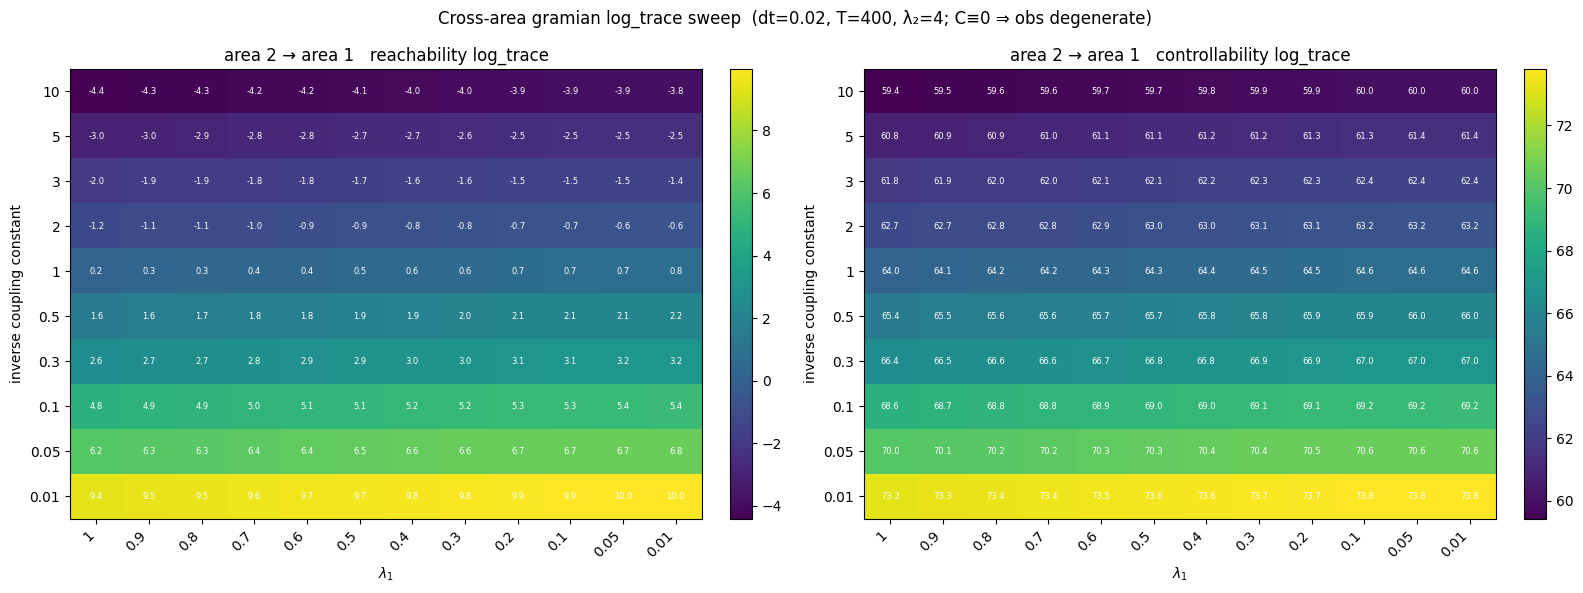

In [5]:
dt, T = 0.02, 400


def _crossgram_logtrace(l1, icc):
    """Canonical area 2 → area 1 (reach, ctrl) log_trace for this
    (λ₁, inv_coupling) — same recipe as the single-pair cell above."""
    Lam = np.diag([-l1, -lambda_2])
    Vm = np.array([[1, 1], [icc, 0]], dtype=float)
    Am = Vm @ Lam @ np.linalg.inv(Vm)
    A_used, B, C_true = float(Am[0, 0]), float(Am[0, 1]), float(Am[1, 0])
    C_c = C_true if abs(C_true) > 1e-12 else 1.0   # reach/ctrl ⟂ C
    seq = lambda x: torch.full((1, T, 1, 1), float(x), dtype=torch.float64)
    (_), (sr, sc, _so) = compute_all_gramians(
        seq(A_used), seq(B), seq(C_c), dt=dt,
        return_sequences=False, return_spectrums=True, rescale=True,
    )
    return (float(torch.logsumexp(sr, dim=-1).item()),
            float(torch.logsumexp(sc, dim=-1).item()))


R_grid = np.empty((len(inv_coupling_const_vals), len(lambda_1_vals)))
C_grid = np.empty_like(R_grid)
for i, icc in enumerate(inv_coupling_const_vals):
    for j, l1 in enumerate(lambda_1_vals):
        R_grid[i, j], C_grid[i, j] = _crossgram_logtrace(l1, icc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, G, ttl in ((axes[0], R_grid, "reachability log_trace"),
                    (axes[1], C_grid, "controllability log_trace")):
    im = ax.imshow(G, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(lambda_1_vals)))
    ax.set_xticklabels(lambda_1_vals, rotation=45, ha="right")
    ax.set_yticks(range(len(inv_coupling_const_vals)))
    ax.set_yticklabels(inv_coupling_const_vals)
    ax.set_xlabel(r"$\lambda_1$")
    ax.set_ylabel("inverse coupling constant")
    ax.set_title(f"area 2 → area 1   {ttl}")
    for i in range(G.shape[0]):
        for j in range(G.shape[1]):
            ax.text(j, i, f"{G[i, j]:.1f}", ha="center", va="center",
                    fontsize=6, color="w")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Cross-area gramian log_trace sweep  (dt={dt}, T={T}, "
             f"λ₂={lambda_2}; C≡0 ⇒ obs degenerate)")
fig.tight_layout()
plt.show()

## Two 4×4 areas: dynamic-stability ↓ ⇒ reach trace ↑ / ctrl trace ↓

In the λ₁ sweep above the knob entered only the input gain `B`, so
reach and ctrl moved *together*. Here we instead make each area a
**4-D block** (full system is 8×8) and sweep a knob that enters the
**target area's own dynamics** — which is what the canonical pipeline
integrates the gramians through — so the genuine reach↑ / ctrl↓
stability tradeoff appears.

    A = [[A_AA ,  g I₄],          A_AA, A_BB = block-diag of two
         [g I₄ ,  A_BB]]          damped 2-D oscillators
                                  [[-d, ω],[-ω,-d]] (freqs ω₁, ω₂)

The damping `d` is the dynamic-stability knob: `d → 0` pushes that
area's eigenvalues toward the imaginary axis ⇒ *less* dynamically
stable. Coupling is mutual `g I₄`.

Canonical pipeline pair **area A → area B** (src = A, target = B),
same convention as the cross-area cell above:
  `A_used = A[B,B] = A_BB`  (target's own 4×4 block — `b` lives here),
  `B = A[B,A] = g I₄`,   `C = A[A,B] = g I₄`.
Reach integrates forward through `M = expm(A_BB·dt)`, ctrl through the
inverse `P = expm(−A_BB·dt)`, so the two respond oppositely as the
target block loses stability. Same `compute_all_gramians(...,
rescale=True)`, `log_trace = logsumexp(spec)`.

reach monotone ↑ ? True   ctrl monotone ↓ ? True
Δreach (b 0.8→0.02) = +2.378   Δctrl = -10.071


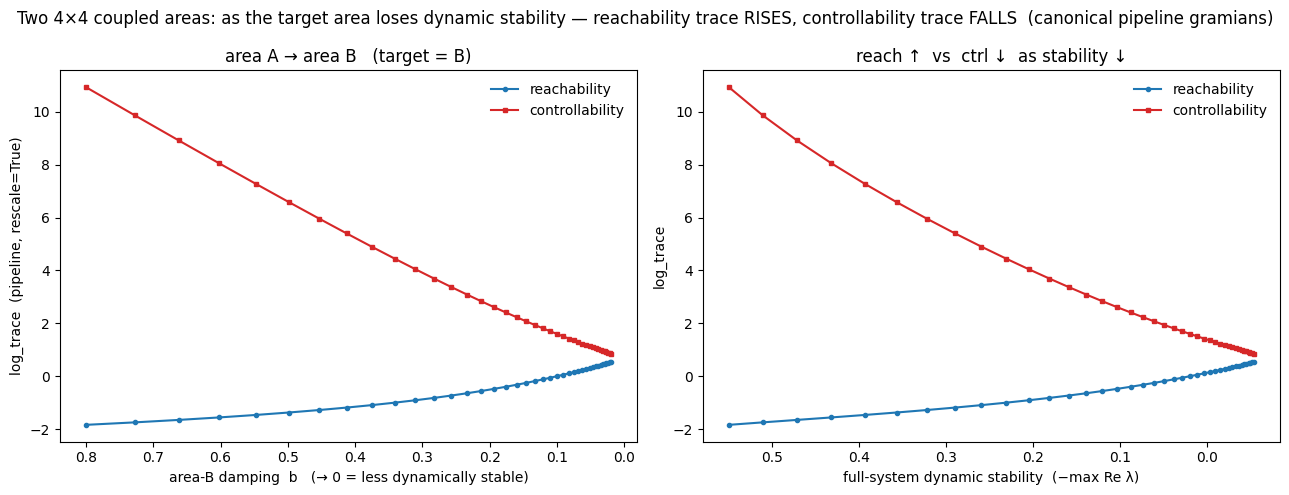

In [6]:
w1, w2, g_cpl = 1.0, 2.3, 0.25         # area mode freqs; mutual coupling
a_src = 0.8                            # source-area (A) damping, fixed
I4 = np.eye(4)


def _area_block(damp):
    """4×4: two damped 2-D oscillators (freqs w1, w2), damping `damp`."""
    o = lambda d, w: np.array([[-d, w], [-w, -d]])
    Z = np.zeros((2, 2))
    return np.block([[o(damp, w1), Z], [Z, o(damp, w2)]])


def _full_A8(b):
    """8×8 two-area system; area-B damping = b (the stability knob)."""
    return np.block([[_area_block(a_src), g_cpl * I4],
                     [g_cpl * I4,         _area_block(b)]])


def _pair_A_to_B(A8):
    """Pipeline convention, src=A (0:4) → tgt=B (4:8):
    A_used = A[B,B], B = A[B,A], C = A[A,B]."""
    sA, sB = slice(0, 4), slice(4, 8)
    return A8[sB, sB], A8[sB, sA], A8[sA, sB]            # A_used, B, C


def _pipe_logtrace_4d(A_used, B, C):
    """Same recipe as the cross-area cell above, with 4-D blocks."""
    seq = lambda M: torch.tensor(M, dtype=torch.float64).reshape(
        1, 1, 4, 4).repeat(1, T, 1, 1)
    (_), (sr, sc, _so) = compute_all_gramians(
        seq(A_used), seq(B), seq(C), dt=dt,
        return_sequences=False, return_spectrums=True, rescale=True)
    return (float(torch.logsumexp(sr, dim=-1).item()),
            float(torch.logsumexp(sc, dim=-1).item()))


b_vals = np.geomspace(0.8, 0.02, 40)   # area-B damping → 0 = less stable
dyn_stab, R_lt, C_lt = [], [], []
for b in b_vals:
    A8 = _full_A8(b)
    dyn_stab.append(-float(np.max(np.real(np.linalg.eigvals(A8)))))
    r, c = _pipe_logtrace_4d(*_pair_A_to_B(A8))
    R_lt.append(r)
    C_lt.append(c)
dyn_stab, R_lt, C_lt = map(np.asarray, (dyn_stab, R_lt, C_lt))

print("reach monotone ↑ ?", bool(np.all(np.diff(R_lt) >= -1e-6)),
      "  ctrl monotone ↓ ?", bool(np.all(np.diff(C_lt) <= 1e-6)))
print("Δreach (b 0.8→0.02) = %+.3f   Δctrl = %+.3f"
      % (R_lt[-1] - R_lt[0], C_lt[-1] - C_lt[0]))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(b_vals, R_lt, "-o", ms=3, color="C0", label="reachability")
ax[0].plot(b_vals, C_lt, "-s", ms=3, color="C3", label="controllability")
ax[0].set_xlabel("area-B damping  b   (→ 0 = less dynamically stable)")
ax[0].set_ylabel("log_trace  (pipeline, rescale=True)")
ax[0].set_title("area A → area B   (target = B)")
ax[0].invert_xaxis()
ax[0].legend(frameon=False)

ax[1].plot(dyn_stab, R_lt, "-o", ms=3, color="C0", label="reachability")
ax[1].plot(dyn_stab, C_lt, "-s", ms=3, color="C3",
           label="controllability")
ax[1].set_xlabel("full-system dynamic stability  (−max Re λ)")
ax[1].set_ylabel("log_trace")
ax[1].set_title("reach ↑  vs  ctrl ↓  as stability ↓")
ax[1].invert_xaxis()                   # left = more stable
ax[1].legend(frameon=False)
fig.suptitle("Two 4×4 coupled areas: as the target area loses dynamic "
             "stability — reachability trace RISES, controllability "
             "trace FALLS  (canonical pipeline gramians)")
fig.tight_layout()
plt.show()

### Regenerate with split y-axes (reach left, ctrl right)

Reach and ctrl `log_trace` live on very different scales here
(Δreach ≈ +2.4, Δctrl ≈ −10), so a shared axis crushes one curve.
Twin y-axes let both spans read clearly. Reuses the same `R_lt`,
`C_lt`, `b_vals`, `dyn_stab` arrays from the sweep cell above.

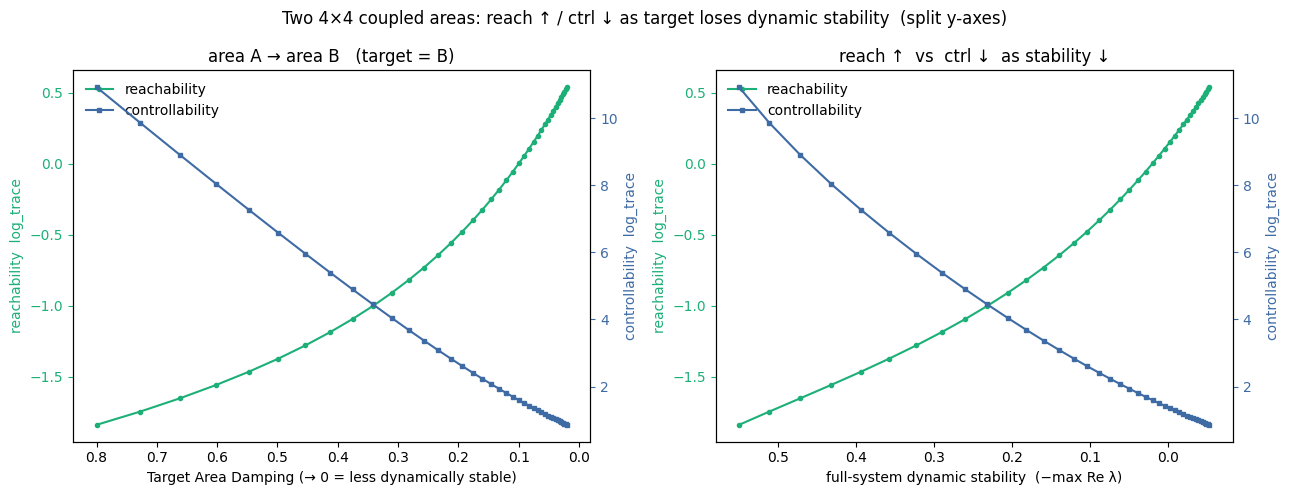

In [7]:
C_REACH = "#1daf78"     # reachability  (green)
C_CTRL  = "#3f6ba5"     # controllability (blue)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# ── left panel: vs damping b ─────────────────────────────────────────
axR, axC = ax[0], ax[0].twinx()
axR.plot(b_vals, R_lt, "-o", ms=3, color=C_REACH, label="reachability")
axC.plot(b_vals, C_lt, "-s", ms=3, color=C_CTRL,  label="controllability")
axR.set_xlabel("Target Area Damping (→ 0 = less dynamically stable)")
axR.set_ylabel("reachability  log_trace", color=C_REACH)
axC.set_ylabel("controllability  log_trace", color=C_CTRL)
axR.tick_params(axis="y", colors=C_REACH)
axC.tick_params(axis="y", colors=C_CTRL)
axR.set_title("area A → area B   (target = B)")
axR.invert_xaxis()
# Combined legend from both axes
lns = axR.get_lines() + axC.get_lines()
axR.legend(lns, [l.get_label() for l in lns], frameon=False, loc="best")

# ── right panel: vs full-system dynamic stability ────────────────────
axR2, axC2 = ax[1], ax[1].twinx()
axR2.plot(dyn_stab, R_lt, "-o", ms=3, color=C_REACH, label="reachability")
axC2.plot(dyn_stab, C_lt, "-s", ms=3, color=C_CTRL,  label="controllability")
axR2.set_xlabel("full-system dynamic stability  (−max Re λ)")
axR2.set_ylabel("reachability  log_trace", color=C_REACH)
axC2.set_ylabel("controllability  log_trace", color=C_CTRL)
axR2.tick_params(axis="y", colors=C_REACH)
axC2.tick_params(axis="y", colors=C_CTRL)
axR2.set_title("reach ↑  vs  ctrl ↓  as stability ↓")
axR2.invert_xaxis()                  # left = more stable
lns2 = axR2.get_lines() + axC2.get_lines()
axR2.legend(lns2, [l.get_label() for l in lns2], frameon=False, loc="best")

fig.suptitle("Two 4×4 coupled areas: reach ↑ / ctrl ↓ as target loses "
             "dynamic stability  (split y-axes)")
fig.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '_notebook/stability_and_control_reach_ctrl.png'

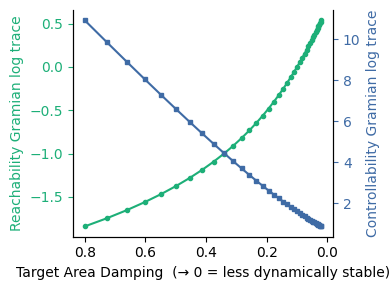

In [ ]:
C_REACH = "#1daf78"     # reachability  (green)
C_CTRL  = "#3f6ba5"     # controllability (blue)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# ── left panel only: vs damping b ────────────────────────────────────
axR = ax
axC = axR.twinx()
axR.plot(b_vals, R_lt, "-o", ms=3, color=C_REACH, label="reachability")
axC.plot(b_vals, C_lt, "-s", ms=3, color=C_CTRL,  label="controllability")
axR.set_xlabel("Target Area Damping  (→ 0 = less dynamically stable)")
axR.set_ylabel("Reachability Gramian log trace", color=C_REACH)
axC.set_ylabel("Controllability Gramian log trace", color=C_CTRL)
axR.tick_params(axis="y", colors=C_REACH)
axC.tick_params(axis="y", colors=C_CTRL)
# Remove the top spline from the plot
axR.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
# axR.set_title("area A → area B   (target = B)")
axR.invert_xaxis()
# Combined legend from both axes
lns = axR.get_lines() + axC.get_lines()
# axR.legend(lns, [l.get_label() for l in lns], frameon=False, loc="best")

fig.tight_layout()
fig.savefig(
    "_notebook/stability_and_control_reach_ctrl.png",
    dpi=200, bbox_inches="tight",
)
plt.show()